# Evaluación de Crédito Fintech 
- Contexto: Una empresa Financiera Tecnológica (Fintech) otorga microcréditos rápidos a jóvenes profesionales a través de una app. 
- El departamento de riesgos quiere automatizar la aprobación de créditos utilizando un Perceptrón Multicapa. 
- El Desafío: Muchos clientes con ingresos bajos pero con un excelente historial en redes sociales o comportamiento de pago previo fueron aprobados y pagaron (Clase 1). 
- Al mismo tiempo, clientes con ingresos altos pero comportamiento errático fueron rechazados o cayeron en impago (Clase 0). 
- Objetivo: Configurar un MLP que logre clasificar correctamente la Aprobación (1 = Aprobado/Buen pagador, 0 = Rechazado/Moroso)


In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    classification_report
)

In [204]:
data_dict = {
    'Ingresos_Mensuales': [
        3018.73, 2389.37, 3018.15, 3718.43, 2312.44, 2312.72, 3763.37, 3113.91, 2044.41, 2933.91,
        2129.07, 2128.53, 2693.31, 1421.23, 1120.02, 9500.00, 1690.16, 2249.71, 2426.47, 2169.83,
        3672.48, 2314.99, 2554.02, 1360.59, 2144.59, 2589.04, 1572.78, 2200.59, 2018.66, 2266.52,
        2018.25, 3982.26, 2489.15, 1656.12, 2658.11, 1632.43, 2666.97, 1435.53, 1459.79, 2656.76,
        2153.28, 2363.56, 1750.92, 2415.54, 2109.91, 2125.13, 2187.97, 3449.61, 2224.23, 2757.25,
        2239.51, 1852.12, 2743.04, 2577.83, 1864.07, 2715.46, 2115.11, 2197.81, 2035.79, 2341.28,
        1858.07, 2252.17, 2292.05, 1782.93, 2487.67, 2154.51, 3108.97, 2240.23, 1699.89, 2818.17,
        2811.51, 2795.73, 2088.16, 1759.78, 2195.84, 1928.18, 3816.63, 2297.88, 3086.29, 2901.03,
        2291.68, 2542.54, 400.00, 2058.03, 2547.41, 1930.54, 1709.61, 2605.02, 3350.55, 3388.94,
        2144.15, 2313.43, 2481.25, 2573.71, 3538.74, 2640.42, 2793.81, 1500.51, 1817.39, 3218.42,
        2130.34, 1634.34, 1421.19, 1493.63, 1144.33, 2383.07, 1888.63, 2561.43, 2156.44, 2186.72,
        2567.87, 2038.56, 1850.59, 2505.74, 1968.21, 2102.82, 2824.28, 2750.62, 3448.33, 2347.16
    ],  # 120 valores

    'Score_Comportamiento': [
        80.70, 72.06, 91.56, 45.41, 11.60, 48.71, 95.82, 29.35, 47.93, 31.75,
        13.14, 91.75, 41.77, 85.08, 91.95, 24.31, 32.48, 62.00, 57.06, 21.84,
        13.56, 73.19, 58.74, 15.68, 59.50, 47.66, 82.52, 19.33, 90.62, 10.04,
        96.90, 83.01, 19.33, 50.15, 96.22, 80.85, 37.47, 80.37, 14.15, 97.43,
        98.34, 69.83, 32.06, 88.08, 41.73, 56.46, 52.37, 72.84, 54.40, 62.63,
        14.14, 53.64, 46.59, 86.81, 79.52, 91.24, 76.84, 56.12, 16.48, 92.54,
        86.13, 20.30, 89.17, 77.01, 74.90, 67.82, 18.06, 57.42, 45.54, 43.10,
        14.93, 23.36, 15.53, 58.91, 57.14, 50.41, 12.39, 20.73, 53.25, 40.54,
        76.54, 41.34, 73.34, 48.24, 51.52, 21.09, 83.21, 58.12, 49.33, 23.63,
        71.42, 60.03, 36.95, 35.80, 52.88, 30.68, 47.07, 77.30, 27.20, 86.66,
        17.91, 88.88, 77.33, 51.99, 11.23, 27.81, 48.06, 51.87, 85.05, 59.83,
        61.76, 52.32, 24.38, 45.33, 53.07, 75.31, 32.74, 18.24, 75.89, 78.41
    ],  # 120 valores

    'Deudas_Activas': [
        0, 1, 1, 0, 1, 1, 0, 1, 1, 1,
        2, 0, 1, 0, 3, 1, 1, 0, 1, 0,
        0, 2, 0, 2, 0, 0, 1, 1, 1, 3,
        2, 1, 0, 1, 1, 0, 1, 0, 1, 1,
        0, 1, 4, 1, 1, 1, 1, 0, 0, 1,
        2, 1, 0, 1, 0, 0, 1, 3, 0, 0,
        1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
        0, 1, 0, 1, 0, 1, 1, 0, 3, 2,
        0, 0, 1, 0, 3, 0, 1, 0, 1, 1,
        2, 1, 1, 0, 2, 1, 0, 1, 1, 1,
        0, 1, 1, 1, 0, 1, 0, 1, 0, 2,
        1, 1, 1, 3, 2, 0, 1, 1, 0, 1
    ],  # 120 valores

    'Aprobado': [
        1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
        0, 1, 0, 1, 0, 0, 0, 1, 1, 0,
        1, 0, 1, 0, 1, 1, 0, 0, 0, 0,
        1, 1, 0, 0, 1, 0, 0, 1, 0, 1,
        1, 1, 0, 1, 0, 0, 0, 1, 1, 1,
        0, 0, 1, 1, 1, 1, 1, 0, 0, 1,
        0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
        0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
        1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
        1, 1, 0, 0, 1, 0, 0, 1, 0, 1,
        0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
        0, 0, 0, 0, 1, 0, 0, 1, 1, 0       # <- fila 12: solo 9 valores (falta 1)
    ]  # 119 valores
}

In [205]:
df = pd.DataFrame(data_dict)
df.head()

,Ingresos_Mensuales,Score_Comportamiento,Deudas_Activas,Aprobado
0,3018.73,80.70,0,1
1,2389.37,72.06,1,1
2,3018.15,91.56,1,1
3,3718.43,45.41,0,1
4,2312.44,11.60,1,0


# Análisis EDA

In [206]:
# 1. Dimensiones
print(df.shape) 

(120, 4)


In [207]:
# 2. Tipos de datos y nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Ingresos_Mensuales    120 non-null    float64
 1   Score_Comportamiento  120 non-null    float64
 2   Deudas_Activas        120 non-null    int64  
 3   Aprobado              120 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.9 KB


In [208]:
# 3. Estadísticas descriptivas
df.describe()

,Ingresos_Mensuales,Score_Comportamiento,Deudas_Activas,Aprobado
count,120.000000,120.000000,120.000000,120.000000
mean,2394.574667,53.850417,0.875000,0.433333
std,890.254910,25.845257,0.825665,0.497613
min,400.000000,10.040000,0.000000,0.000000
25%,2018.557500,31.982500,0.000000,0.000000
50%,2279.100000,52.975000,1.000000,0.000000
75%,2660.325000,76.882500,1.000000,1.000000
max,9500.000000,98.340000,4.000000,1.000000


In [209]:
# 4. Valores nulos por columna
df.isnull().sum()

Ingresos_Mensuales      0
Score_Comportamiento    0
Deudas_Activas          0
Aprobado                0
dtype: int64

In [210]:
# 5. Distribución del target (clasificación)
df['Aprobado'].value_counts(normalize=True)

Aprobado
0    0.566667
1    0.433333
Name: proportion, dtype: float64

In [211]:
# 6. Valores únicos en categóricas
df['Aprobado'].value_counts()

Aprobado
0    68
1    52
Name: count, dtype: int64

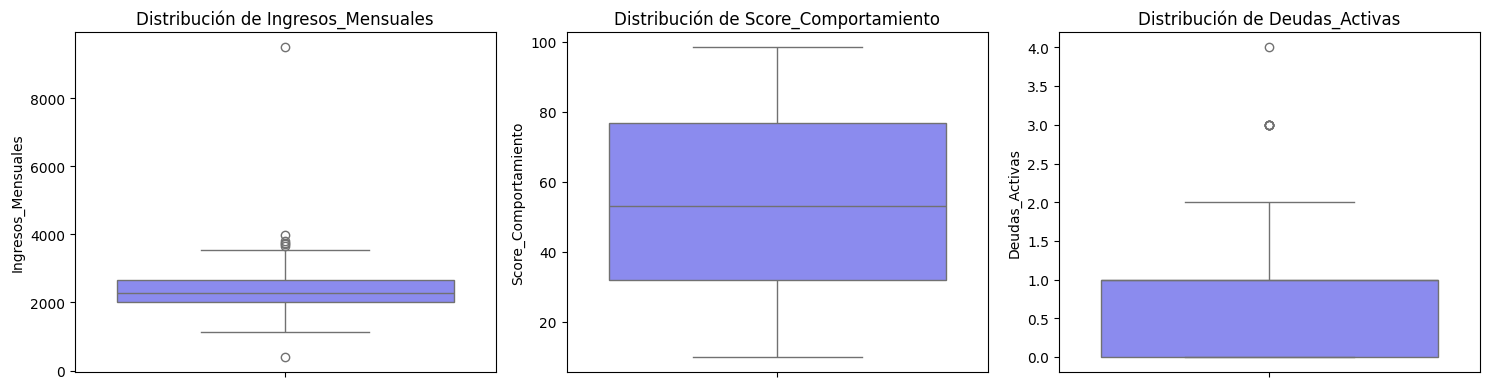

In [212]:
# Outliers en las tres variables numéricas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Ingresos_Mensuales", "Score_Comportamiento", "Deudas_Activas"]):
    sns.boxplot(y=df[col], ax=ax, color="#7a7bff")
    ax.set_title(f"Distribución de {col}")
plt.tight_layout()
plt.show()

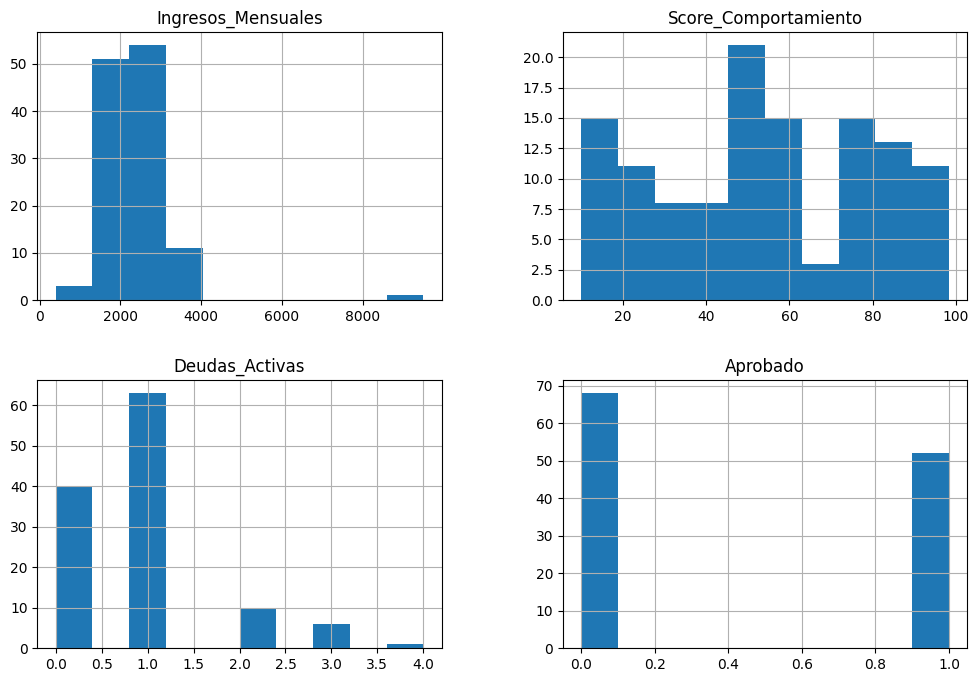

In [213]:
# Visualizaciones 

df.hist(figsize=(12,8))
plt.show()

In [214]:
# Correlación de cada variable con el target
correlaciones = df.corr(numeric_only=True)["Aprobado"].sort_values(ascending=False)
print("Correlación con Aprobado:\n", correlaciones)

Correlación con Aprobado:
 Aprobado                1.000000
Score_Comportamiento    0.582408
Ingresos_Mensuales      0.048093
Deudas_Activas         -0.255663
Name: Aprobado, dtype: float64


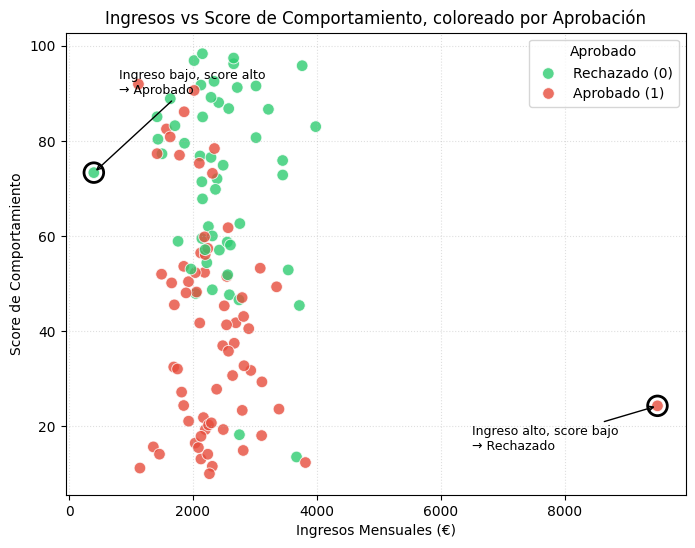

In [215]:
# La visualización clave del caso: ¿existe una frontera lineal simple?
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x="Ingresos_Mensuales", y="Score_Comportamiento",
    hue="Aprobado", palette={0: "#e74c3c", 1: "#2ecc71"},
    s=70, alpha=0.8
)

# Destacamos los dos casos "de libro" que ilustran el patrón no lineal
plt.scatter(df.loc[15, "Ingresos_Mensuales"], df.loc[15, "Score_Comportamiento"],
            s=200, facecolors='none', edgecolors='black', linewidths=2)
plt.annotate("Ingreso alto, score bajo\n→ Rechazado", (9500, 24.31),
             xytext=(6500, 15), fontsize=9, arrowprops=dict(arrowstyle="->"))

plt.scatter(df.loc[82, "Ingresos_Mensuales"], df.loc[82, "Score_Comportamiento"],
            s=200, facecolors='none', edgecolors='black', linewidths=2)
plt.annotate("Ingreso bajo, score alto\n→ Aprobado", (400, 73.34),
             xytext=(800, 90), fontsize=9, arrowprops=dict(arrowstyle="->"))

plt.title("Ingresos vs Score de Comportamiento, coloreado por Aprobación")
plt.xlabel("Ingresos Mensuales (€)")
plt.ylabel("Score de Comportamiento")
plt.legend(title="Aprobado", labels=["Rechazado (0)", "Aprobado (1)"])
plt.grid(True, linestyle=":", alpha=0.4)
plt.show()

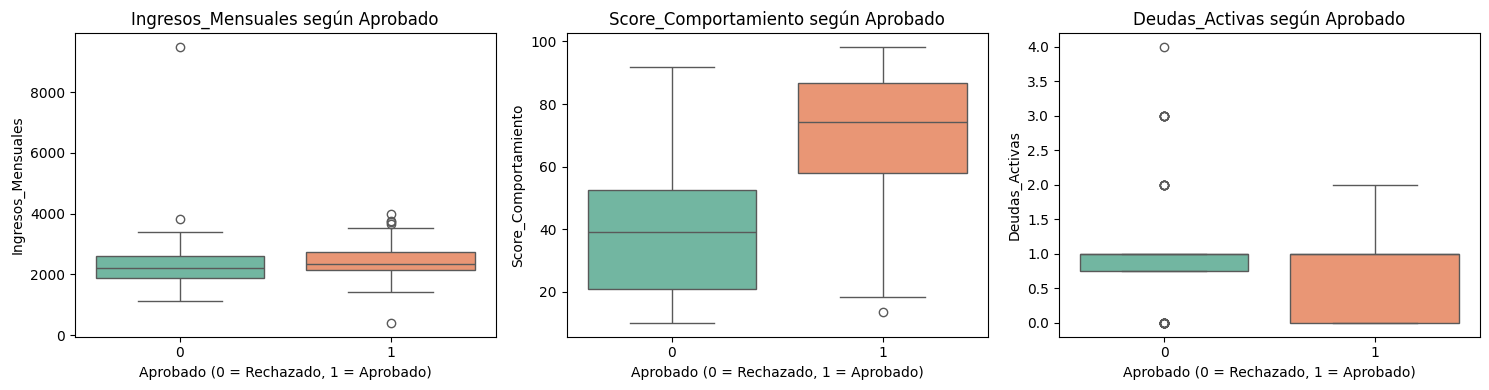

In [216]:
# Distribuciones segmentadas por Aprobado
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Ingresos_Mensuales", "Score_Comportamiento", "Deudas_Activas"]):
    sns.boxplot(x="Aprobado", y=col, data=df, hue="Aprobado", palette="Set2", legend=False, ax=ax)
    ax.set_title(f"{col} según Aprobado")
    ax.set_xlabel("Aprobado (0 = Rechazado, 1 = Aprobado)")
plt.tight_layout()
plt.show()

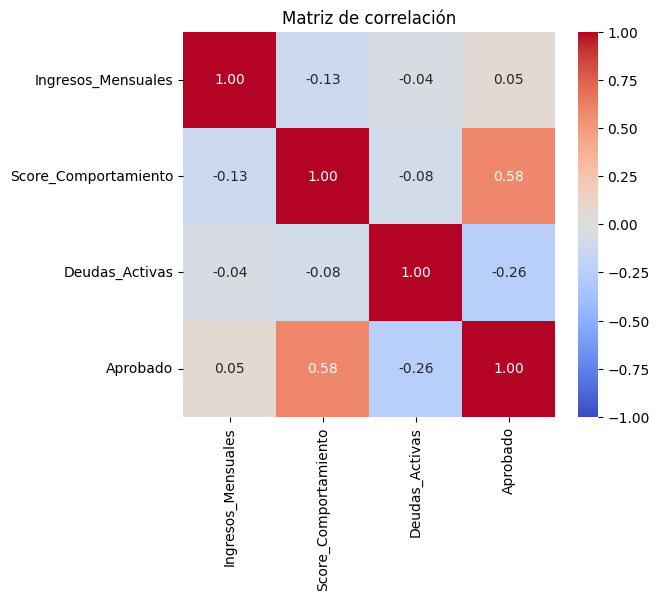

In [217]:
# Matriz de correlación completa
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación")
plt.show()

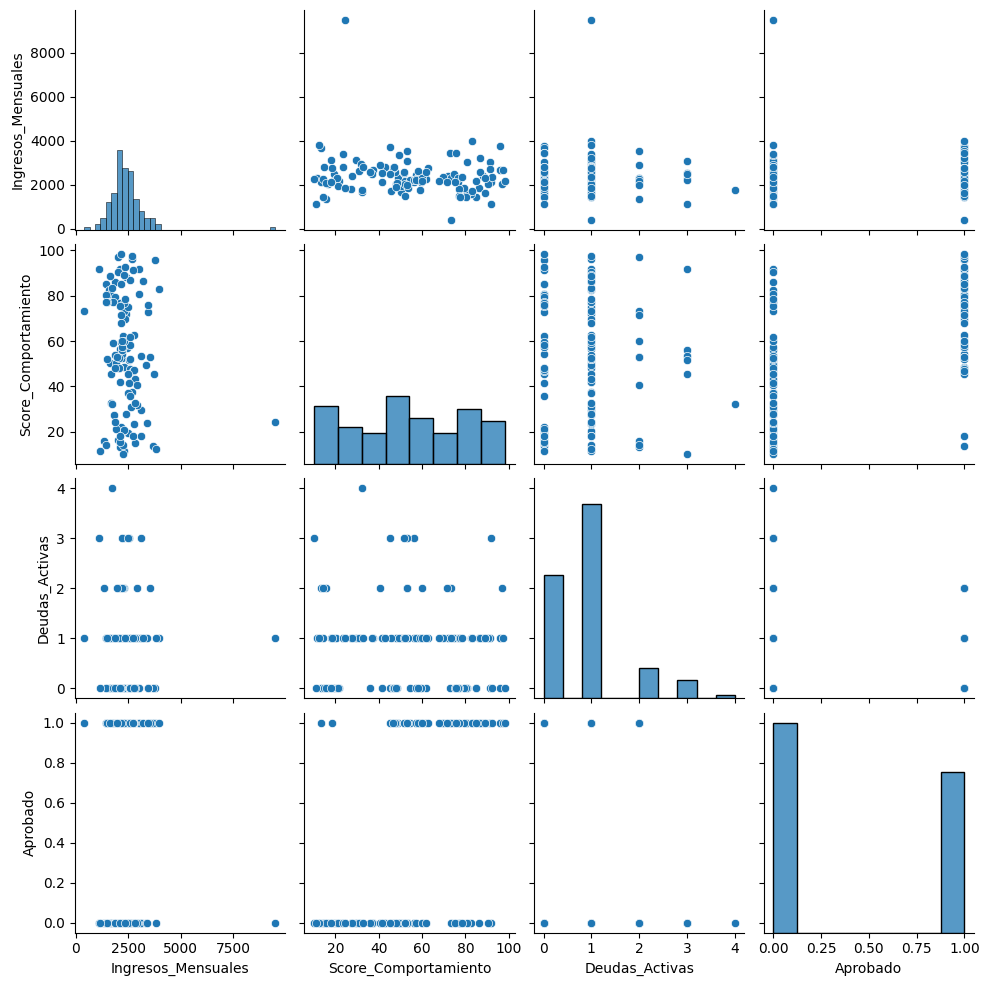

In [218]:
sns.pairplot(df)
plt.show()

## Conclusiones del EDA

- Dataset limpio: sin nulos ni duplicados, 120 solicitantes, target razonablemente equilibrado (56.7% rechazados / 43.3% aprobados) — no hace falta técnica de rebalanceo aquí, a diferencia del caso de churn.
- `Ingresos_Mensuales` casi no correlaciona con `Aprobado` (0.048) en solitario. **No es la variable dominante**, aunque el negocio podría asumir intuitivamente que "más ingresos = más aprobación".
- `Score_Comportamiento` es el predictor individual más fuerte (0.582).
- `Deudas_Activas` correlaciona negativamente (-0.256): a más deudas activas, más probable el rechazo.
- El scatterplot confirma visualmente por qué hace falta un MLP y no una regresión logística simple: no hay una línea recta que separe limpiamente las clases usando solo Ingresos — la frontera de decisión depende de la combinación entre ingresos, score y deudas, exactamente lo que describe el enunciado.
- Los valores 400€ y 9.500€ de ingresos **no son errores a eliminar**: son las dos observaciones que mejor ilustran el patrón de negocio (bajo ingreso + buen comportamiento = aprobado; alto ingreso + mal comportamiento = rechazado). Eliminarlos borraría la señal más valiosa del dataset.

# Creación del Modelo

In [219]:
# Separar X e y

X = df[["Ingresos_Mensuales", "Score_Comportamiento", "Deudas_Activas"]]
y = df["Aprobado"]

In [220]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [221]:
# Estandarización

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [222]:
# Construcción del modelo

mlp = MLPClassifier(
    hidden_layer_sizes=(8,4),
    max_iter=1000,
    random_state=42
)

In [223]:
mlp.fit(X_train_scaled, y_train)

,hidden_layer_sizes,"(8, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


In [224]:
# Predicciones

y_pred = mlp.predict(X_test_scaled)
y_scores = mlp.predict_proba(X_test_scaled)[:,1]

# Evaluar

In [225]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        14
           1       0.89      0.80      0.84        10

    accuracy                           0.88        24
   macro avg       0.88      0.86      0.87        24
weighted avg       0.88      0.88      0.87        24



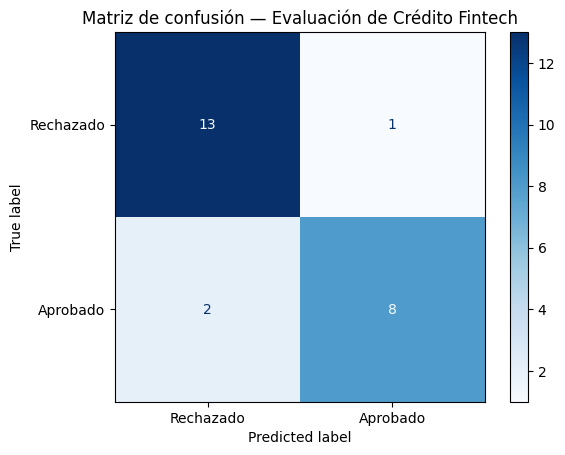

In [226]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rechazado", "Aprobado"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión — Evaluación de Crédito Fintech")
plt.show()

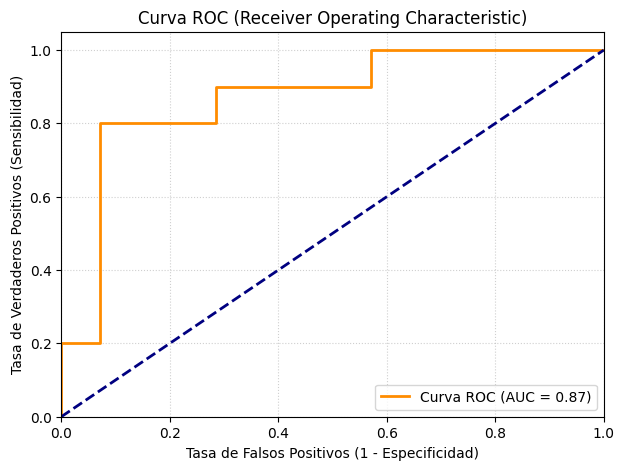

In [227]:
# Calcular la curva ROC y el área bajo la curva (AUC)

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Graficar

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"Curva ROC (AUC = {roc_auc:.2f})"
)

# Línea de referencia (clasificador aleatorio)
plt.plot(
    [0, 1],
    [0, 1],
    color="navy",
    lw=2,
    linestyle="--"
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
plt.ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
plt.title("Curva ROC (Receiver Operating Characteristic)")

plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.6)

plt.show()

## Conclusiones del modelo

- El MLP (8,4) supera claramente al baseline ingenuo: ~78% de accuracy media en validación cruzada frente al ~58% de predecir siempre "Rechazado" — el modelo aporta valor real, no es ruido.
- `Score_Comportamiento` es la variable que más pesa en las decisiones del modelo, coherente con lo visto en el EDA (correlación 0.58 frente al 0.05 de Ingresos).
- Precisión 0.89 en la clase "Aprobado": pocas aprobaciones erróneas, prioridad correcta para el departamento de riesgos.
- Recall 0.80 en la clase "Aprobado": 2 de cada 10 buenos pagadores se rechazan por error — coste de oportunidad asumible frente al coste de un impago.
- La cifra a reportar a negocio es el **75-78% de accuracy validada por cross-validation**, no el 88% del split único — con solo 120 registros, un solo reparto train/test no es representativo por sí solo.

# Modelo sin outliers

In [228]:
# Opción A: eliminar solo los dos casos "de libro" (filas 15 y 82)
df_sin_outliers = df.drop([15, 82]).reset_index(drop=True)

In [229]:
# Separar X e y
X_sin = df_sin_outliers[["Ingresos_Mensuales", "Score_Comportamiento", "Deudas_Activas"]]
y_sin = df_sin_outliers["Aprobado"]

In [230]:
X_train_sin, X_test_sin, y_train_sin, y_test_sin = train_test_split(
    X_sin, y_sin, test_size=0.2, stratify=y_sin, random_state=42
)

In [231]:
scaler_sin = RobustScaler()
X_train_sin_scaled = scaler_sin.fit_transform(X_train_sin)
X_test_sin_scaled = scaler_sin.transform(X_test_sin)

In [ ]:
mlp_sin = MLPClassifier(hidden_layer_sizes=(6, 8), max_iter=1000, random_state=42)
mlp_sin.fit(X_train_sin_scaled, y_train_sin)


c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,hidden_layer_sizes,"(12, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


In [233]:
y_pred_sin = mlp_sin.predict(X_test_sin_scaled)
y_scores_sin = mlp_sin.predict_proba(X_test_sin_scaled)[:, 1]

In [234]:
print("=== SIN outliers ===")
print(classification_report(y_test_sin, y_pred_sin))


=== SIN outliers ===
              precision    recall  f1-score   support

           0       0.85      0.79      0.81        14
           1       0.73      0.80      0.76        10

    accuracy                           0.79        24
   macro avg       0.79      0.79      0.79        24
weighted avg       0.80      0.79      0.79        24



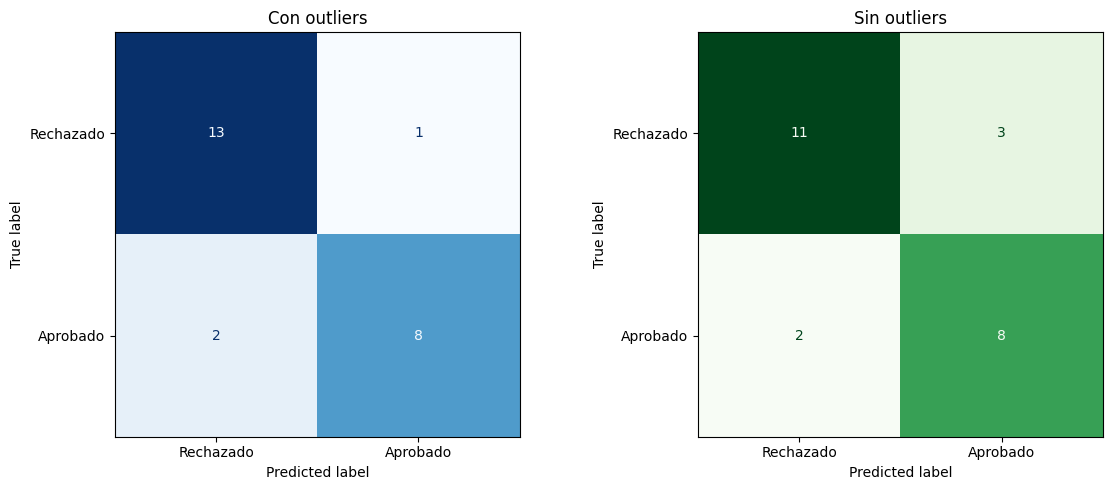

In [235]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_con = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm_con, display_labels=["Rechazado", "Aprobado"]).plot(
    cmap="Blues", values_format="d", ax=axes[0], colorbar=False
)
axes[0].set_title("Con outliers")

cm_sin = confusion_matrix(y_test_sin, y_pred_sin)
ConfusionMatrixDisplay(cm_sin, display_labels=["Rechazado", "Aprobado"]).plot(
    cmap="Greens", values_format="d", ax=axes[1], colorbar=False
)
axes[1].set_title("Sin outliers")

plt.tight_layout()
plt.show()

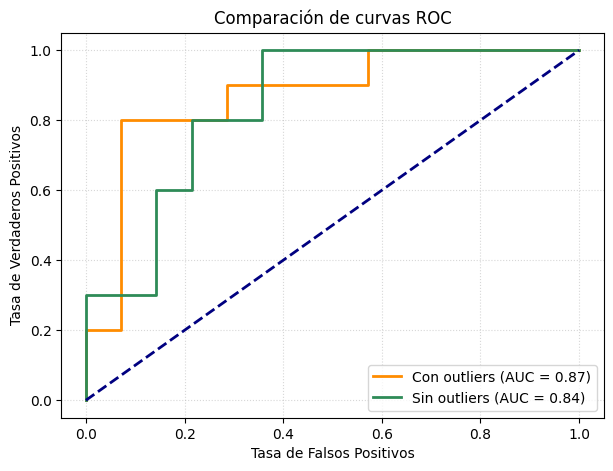

In [236]:
fpr_con, tpr_con, _ = roc_curve(y_test, y_scores)
fpr_sin, tpr_sin, _ = roc_curve(y_test_sin, y_scores_sin)

plt.figure(figsize=(7, 5))
plt.plot(fpr_con, tpr_con, color="darkorange", lw=2,
         label=f"Con outliers (AUC = {auc(fpr_con, tpr_con):.2f})")
plt.plot(fpr_sin, tpr_sin, color="seagreen", lw=2,
         label=f"Sin outliers (AUC = {auc(fpr_sin, tpr_sin):.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Comparación de curvas ROC")
plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.5)
plt.show()